In [419]:
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import matplotlib.patches as mpatches # type: ignore
import numpy as np
import glob
import os

In [420]:
plt.rcParams["font.family"] = "Helvetica Neue"
os.makedirs("figures", exist_ok=True)

# Export most up to date samples

In [421]:
FILE = "Workflow_Analysis.xlsx"
OUTPUT_FOLDER = "csv_exports"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

sheets = pd.read_excel(FILE, sheet_name=None)
sheets = {k: v for k, v in sheets.items() if k.startswith("Video")}

for sheet_name, df in sheets.items():
    # Extract numbers from "Video-X-Sample-Y" -> "X_Y"
    parts = sheet_name.split("-")
    simple_name = f"{parts[1]}_{parts[3]}"
    
    df.to_csv(os.path.join(OUTPUT_FOLDER, f"{simple_name}.csv"), index=False)
    print(f"Exported: {sheet_name} : {simple_name}.csv")

print(f"\nDone — {len(sheets)} sheets exported to '{OUTPUT_FOLDER}/'")

Exported: Video-1-Sample-1 : 1_1.csv
Exported: Video-2-Sample-1 : 2_1.csv
Exported: Video-3-Sample-1 : 3_1.csv
Exported: Video-4-Sample-1 : 4_1.csv
Exported: Video-5-Sample-1 : 5_1.csv
Exported: Video-6-Sample-1 : 6_1.csv
Exported: Video-7-Sample-1 : 7_1.csv
Exported: Video-8-Sample-1 : 8_1.csv
Exported: Video-9-Sample-1 : 9_1.csv
Exported: Video-10-Sample-1 : 10_1.csv

Done — 10 sheets exported to 'csv_exports/'


# Sampling Saturation

In [422]:
CSV_FOLDER  = "./csv_exports"  
csv_files = sorted(
    glob.glob(os.path.join(CSV_FOLDER, "*.csv")),
    key=lambda f: [int(x) for x in os.path.splitext(os.path.basename(f))[0].split("_")]
)

In [423]:
csv_files

['./csv_exports/1_1.csv',
 './csv_exports/2_1.csv',
 './csv_exports/3_1.csv',
 './csv_exports/4_1.csv',
 './csv_exports/5_1.csv',
 './csv_exports/6_1.csv',
 './csv_exports/7_1.csv',
 './csv_exports/8_1.csv',
 './csv_exports/9_1.csv',
 './csv_exports/10_1.csv']

In [424]:
CODE_COLUMN = "action"         

def saturation(csv_files, code_column):
    seen_codes  = set() # sets are used because they contain unique items with no duplicates

    new_per_sample = []
    cumulative  = []
    sample_labels = []
    
    for filepath in csv_files:
        label = os.path.splitext(os.path.basename(filepath))[0]  # filename without extension
        sample_labels.append(label)
        
        df = pd.read_csv(filepath)
        df = df.dropna(subset=[code_column])
        
        codes_in_sample = set(df[code_column].unique())
        new_codes = codes_in_sample - seen_codes
        
        seen_codes.update(codes_in_sample) # add new codes
        
        new_per_sample.append(len(new_codes))
        cumulative.append(len(seen_codes))


    # combine all CSVs in order
    all_dfs = [pd.read_csv(f) for f in csv_files]
    df_all = pd.concat(all_dfs, ignore_index=True)
    df_all = df_all.dropna(subset=[code_column])
    
    # track saturation row by row
    seen_codes = set()
    cumulative_interactions = []
    cumulative_unique = []
    
    for i, row in df_all.iterrows():
        code = row[code_column]
        seen_codes.add(code)
        itr = i + 1
        cumulative_interactions.append(itr)
        cumulative_unique.append(len(seen_codes))
        
    fig, ax = plt.subplots(figsize=(9, 4.5))
    fig.patch.set_facecolor("#FFFFFF")
    ax.set_facecolor("#FFFFFF")
    ax.plot(cumulative_interactions, cumulative_unique, color="#A8C8E8", linewidth=2)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlabel("Total interactions coded")
    ax.set_ylabel("Cumulative unique codes")
    plt.tight_layout()
    
    sample_boundaries = []
    total = 0
    for f in csv_files:
        df_temp = pd.read_csv(f).dropna(subset=[code_column])
        sample_boundaries.append(total)
        total += len(df_temp)
        
    # add vertical lines
    for boundary in sample_boundaries[1:]:  # skip the first (it's just 0)
        ax.axvline(x=boundary, color="#CCCCCC", linewidth=0.8, linestyle="--")
        
    ax.set_title(f"{code_column} saturation", fontsize=12, color="#444", pad=12)
    plt.savefig(f"figures/saturation_{code_column}.png", dpi=150, bbox_inches="tight")
    

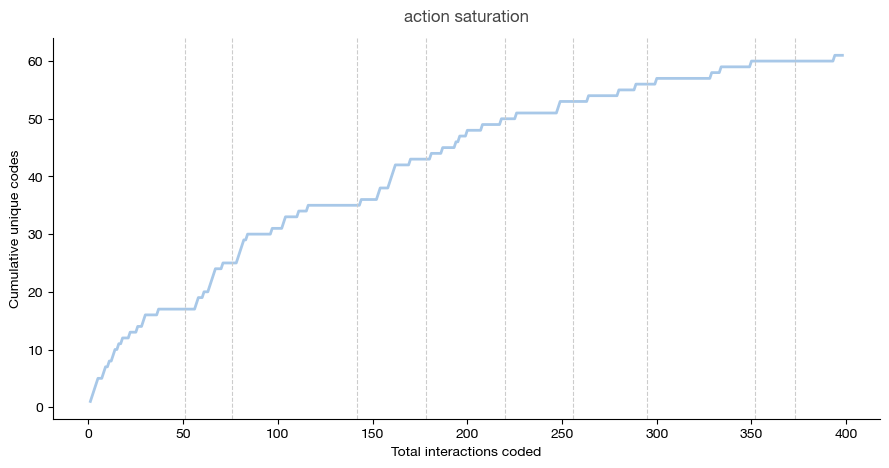

In [425]:
saturation(csv_files=csv_files, code_column="action")

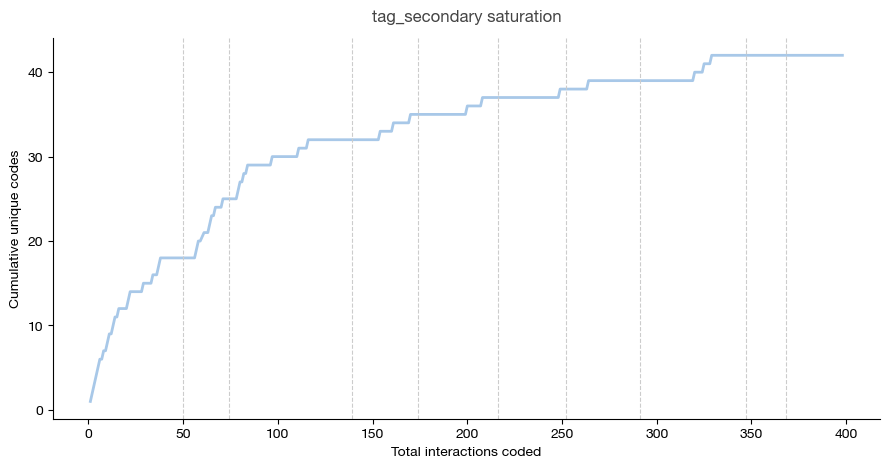

In [426]:
saturation(csv_files=csv_files, code_column="tag_secondary") 

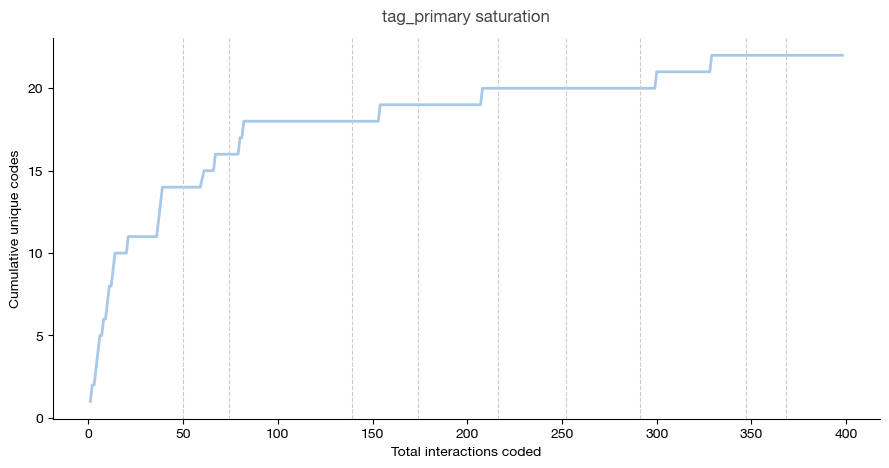

In [427]:
saturation(csv_files=csv_files, code_column="tag_primary") 

# Analysis

In [428]:
dfs = []
for filepath in sorted(glob.glob("csv_exports/*.csv")):
    _df = pd.read_csv(filepath)
    _df["sample"] = os.path.splitext(os.path.basename(filepath))[0]
    dfs.append(_df)

df = pd.concat(dfs, ignore_index=True)
df = df[df["action"].notna() & (df["action"] != "[mistake/redundant]")]
print(f"Loaded {len(df)} rows from {len(dfs)} samples")

Loaded 392 rows from 10 samples


In [429]:
df["start"]                    = pd.to_numeric(df["start"],                    errors="coerce")
df["end"]                      = pd.to_numeric(df["end"],                      errors="coerce")
df["duration"]                 = pd.to_numeric(df["duration"],                 errors="coerce")
df["true_duration_unlabelled"] = pd.to_numeric(df["true_duration_unlabelled"], errors="coerce")
df["estimated_duration"]       = pd.to_numeric(df["estimated_duration"],       errors="coerce")

df["tag"]    = df["tag_primary"].str.strip()
df["how"]    = df["how_primary"].str.strip()
df["action"] = df["action"].str.strip()
df["secondary"] = df["tag_secondary"].str.strip()

# optional for mapping difficulty and creating action bundles
# df["difficulty"]    = df["action"].map(difficulty_map)
# df["action_bundle"] = df["action"].map(action_groups)
# df["tag_group"]     = df["tag"].map(tag_groups).fillna(df["tag"])
# df["subtype"]       = df["tag"].map(get_subtype)

df = df.drop(columns=["Title", "video", "initial_code", "intent"
                       "difficulty_with_existing_speech_tools", "how_secondary", "insights_and_notes"],
             errors="ignore")

df.head()

,sample,start,end,action,difficulty_with_existing_speech_tools,tag_primary,tag_secondary,how_primary,location,intent,adjusted_start,adjusted_end,duration,true_duration,true_duration_unlabelled,estimated_duration,tag,how,secondary
0,10_1,57.00,57.02,[zoom] to fit context in viewport,NaN,navigation,navigate to fit context,complex gesture,canvas,wayfinding,0.0,2.0,2.0,<3 seconds,3.0,2.5,navigation,complex gesture,navigate to fit context
1,10_1,57.02,57.03,[navigate] to focus [reference],NaN,navigation,navigate to reference,complex gesture,canvas,wayfinding,2.0,3.0,1.0,<2 seconds,2.0,1.5,navigation,complex gesture,navigate to reference
2,10_1,57.04,57.05,[hover] over [reference(s)] in [layers panel],NaN,wayfinding,wayfinding using layers,cursor,layers panel,wayfinding,4.0,5.0,1.0,<2 seconds,2.0,1.5,wayfinding,cursor,wayfinding using layers
3,10_1,57.06,57.06,[gui interaction],NaN,gui interaction,gui interaction,cursor,gui,NaN,6.0,6.0,0.0,<1 second,1.0,0.5,gui interaction,cursor,gui interaction
4,10_1,57.07,57.10,[gui interaction],NaN,gui interaction,gui interaction,gesture,gui,NaN,7.0,10.0,3.0,<4 seconds,4.0,3.5,gui interaction,gesture,gui interaction


## Exploratory Analysis

In [430]:
print(df["tag"].value_counts())

tag
selection                        92
navigation                       83
positioning                      48
gui interaction                  47
wayfinding                       24
resizing                         21
creating design object           13
grouping                         12
copy/paste/cut                    8
creating spline object            7
update colour                     6
update text object content        6
undo                              6
delete                            5
creating text                     2
update text object property       2
update text object size           2
update design object property     2
alignment guides                  2
switch to another app             2
rename                            1
enter vector editing mode         1
Name: count, dtype: int64


In [431]:
print(df["location"].value_counts())

location
canvas          312
gui              70
layers panel     10
Name: count, dtype: int64


In [432]:
print(df["true_duration_unlabelled"].describe())
print()
print(df["duration"].describe())

count    392.000000
mean       1.813776
std        1.931967
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       21.000000
Name: true_duration_unlabelled, dtype: float64

count    392.000000
mean       0.813776
std        1.931967
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max       20.000000
Name: duration, dtype: float64


In [450]:
print(df["how_primary"].value_counts())

how_primary
cursor             258
complex gesture     43
gesture             42
keyboard            39
multi_step           8
multi_input          2
Name: count, dtype: int64


In [ ]:
cursor = 258
complex_gesture =43
gesture = 42
keyboard = 39
multi_step= 8

In [452]:
hows = [cursor, complex_gesture, gesture, keyboard, multi_step]

for elem in hows:
    print(elem/397)

0.6498740554156172
0.10831234256926953
0.10579345088161209
0.0982367758186398
0.020151133501259445


In [453]:
0.10831234256926953 + 0.10579345088161209

0.2141057934508816

In [433]:
# df["difficulty"].value_counts()

## Visualisations

In [434]:
df_no_gui = df[
    (df["tag_primary"] != "gui interaction") &
    (df["tag_secondary"] != "gui interaction") &
    (df["action"] != "[gui interaction]")
]

In [435]:
PALETTE = [
    '#F28B82', '#F5A882', '#F0B8D8', '#FAD080',
    '#B5E0A8', '#A8D8C8', '#B8E8D8',
    '#A8C8E8', '#C8E0F0',
    '#A8A8E8', '#C8B8F0', '#E8C8F0',
]

BG = "#FFFFFF"

def bar_style(ax):
    """Apply consistent minimal style to a bar chart axis."""
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#ddd")
    ax.yaxis.grid(True, color="#f0f0f0", zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(axis="y", labelsize=9, colors="#666")
    ax.set_ylabel("Count", fontsize=10, color="#888")

def add_bar_labels(ax, bars, values):
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.2,
                str(val), ha="center", fontsize=9, color="#666")

all_tags = df["tag"].value_counts().index.tolist()
global_color_map = {tag: PALETTE[i % len(PALETTE)] for i, tag in enumerate(all_tags)}

In [436]:
def create_bar(df_plot, num=15, output="graph"):
    df_plot = df_plot.head(num)
    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
    bars = ax.bar(df_plot.index, df_plot.values, color="#9DD5FC", edgecolor="none", width=0.7)
    add_bar_labels(ax, bars, df_plot.values)
    bar_style(ax)
    ax.set_xticklabels(df_plot.index, rotation=45, ha="right", fontsize=9, color="#666")
    ax.set_title(f"{output} frequency (top {num})", fontsize=12, color="#444", pad=12)
    plt.tight_layout()
    plt.savefig(f"figures/frequency_{output}.png", dpi=150, bbox_inches="tight", facecolor=BG)
    plt.show()
    

/var/folders/hd/bt5ny1sx6hz3vyh2p56cyyvc0000gn/T/ipykernel_38930/3619881053.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_plot.index, rotation=45, ha="right", fontsize=9, color="#666")


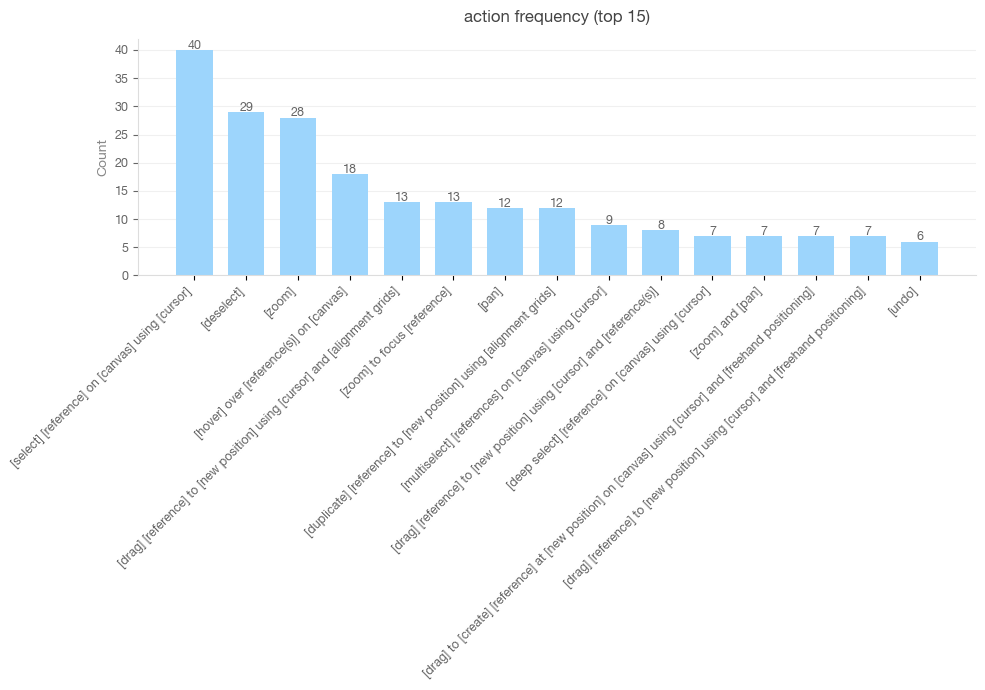

In [437]:
# df_plot = df["action"].value_counts().sort_values(ascending=False).head(15)
df_plot = df_no_gui["action"].value_counts().sort_values(ascending=False)

create_bar(df_plot, num=15, output="action")


/var/folders/hd/bt5ny1sx6hz3vyh2p56cyyvc0000gn/T/ipykernel_38930/3619881053.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_plot.index, rotation=45, ha="right", fontsize=9, color="#666")


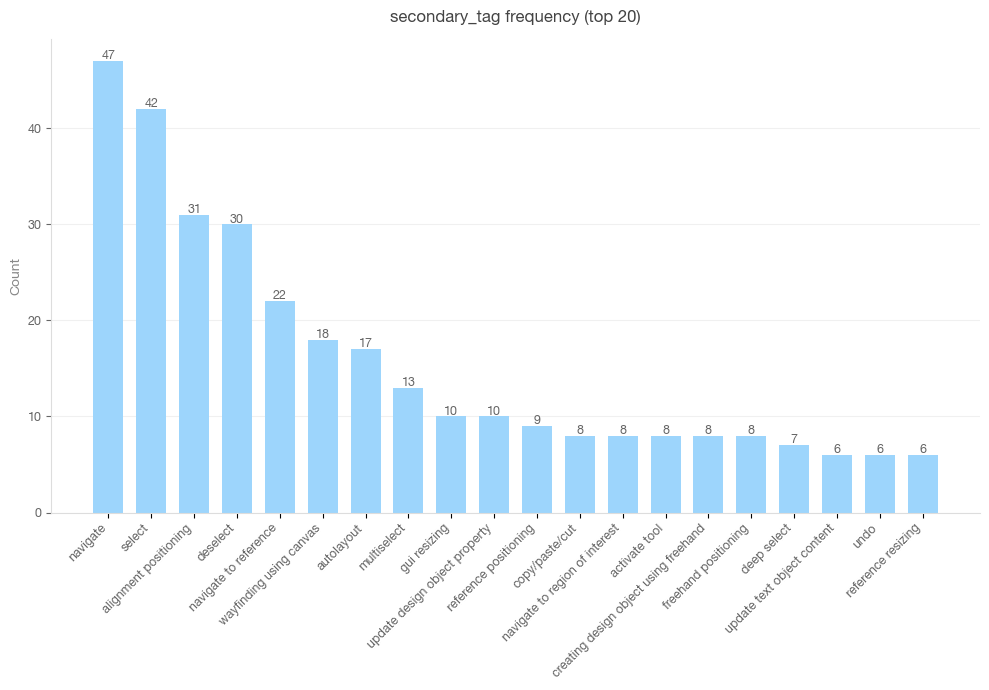

In [438]:
# df_plot = df["tag_secondary"].value_counts().sort_values(ascending=False)
# df_plot = df_no_gui["tag_secondary"].value_counts().sort_values(ascending=False)

df_plot = df[(df["tag_secondary"] != "gui interaction")]["tag_secondary"].value_counts().sort_values(ascending=False)

create_bar(df_plot, num=20, output="secondary_tag")

/var/folders/hd/bt5ny1sx6hz3vyh2p56cyyvc0000gn/T/ipykernel_38930/3619881053.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_plot.index, rotation=45, ha="right", fontsize=9, color="#666")


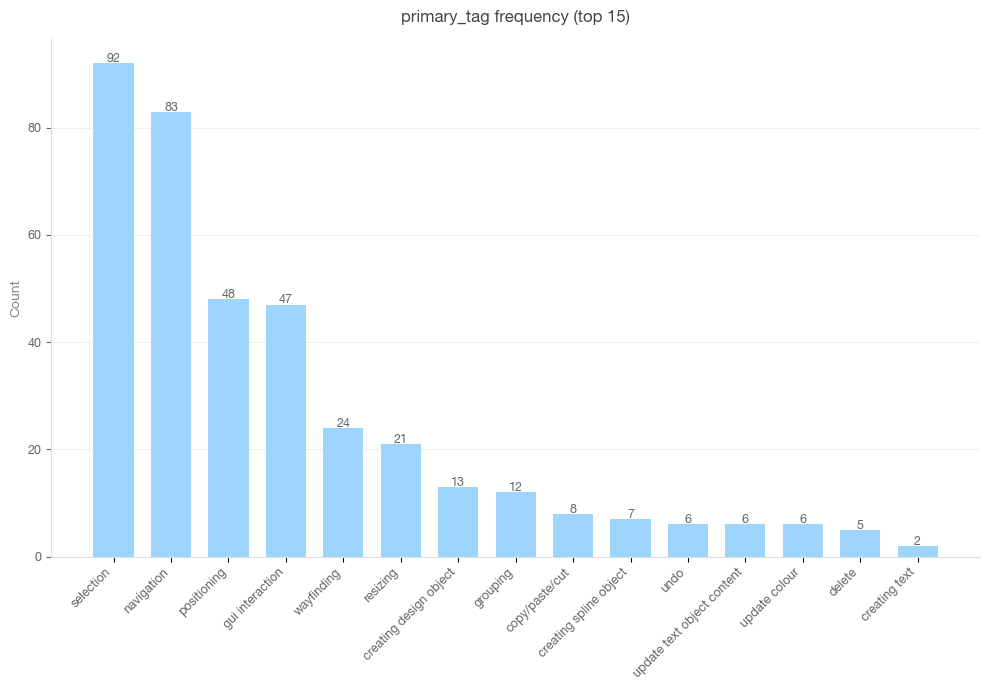

In [439]:
df_plot = df["tag_primary"].value_counts().sort_values(ascending=False)
# df_plot = df_no_gui["tag_primary"].value_counts().sort_values(ascending=False).head(20)

create_bar(df_plot, num=15, output="primary_tag")

## Subgraphs based on selection

In [440]:
df_selection = df[df["tag_primary"] == "selection"]

In [441]:
df_selection["action"].value_counts()

action
[select] [reference] on [canvas] using [cursor]                    40
[deselect]                                                         29
[multiselect] [references] on [canvas] using [cursor]               9
[deep select] [reference] on [canvas] using [cursor]                7
[drag] to [multiselect] [references] on [canvas] using [cursor]     4
[select] [reference] on [layers panel] using [cursor]               2
[deselect] [reference]                                              1
Name: count, dtype: int64

/var/folders/hd/bt5ny1sx6hz3vyh2p56cyyvc0000gn/T/ipykernel_38930/3619881053.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_plot.index, rotation=45, ha="right", fontsize=9, color="#666")


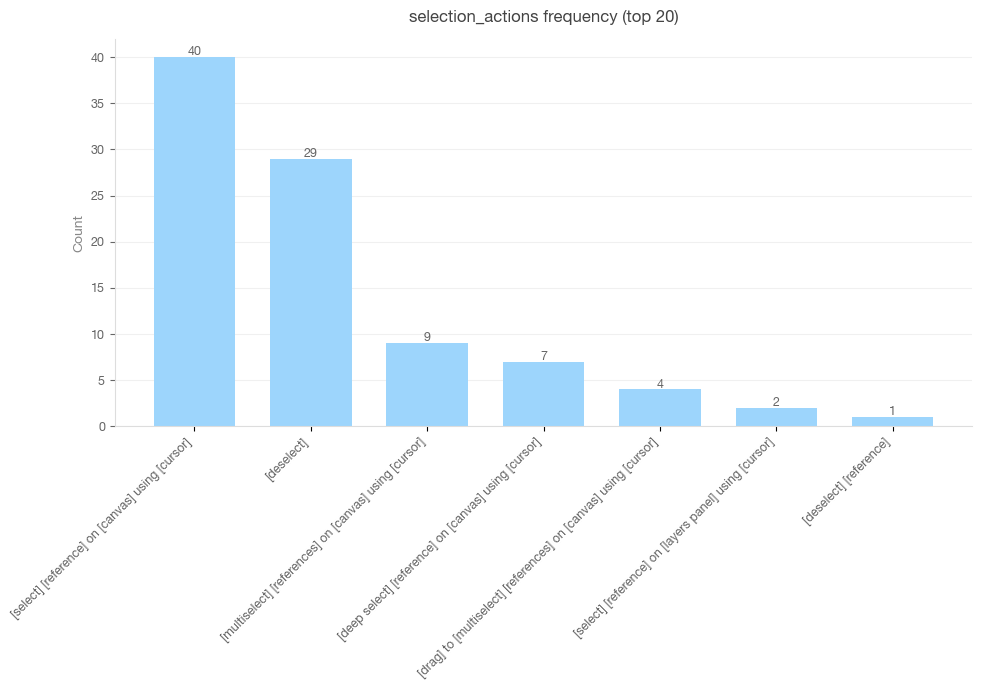

In [442]:
df_plot = df_selection["action"].value_counts().sort_values(ascending=False)
create_bar(df_plot, num=20, output="selection_actions")

## Subgraphs based on navigation

In [443]:
df_navigation = df[df["tag_primary"] == "navigation"]

In [444]:
df_navigation["action"].value_counts()

action
[zoom]                                    28
[zoom] to focus [reference]               13
[pan]                                     12
[zoom] and [pan]                           7
[zoom] to fit context in viewport          6
[navigate] to focus [reference]            5
[pan] to focus [reference]                 4
[zoom] to focus [area of interest]         4
[navigate] to focus [area of interest]     3
[pan] to focus [area of interest]          1
Name: count, dtype: int64

/var/folders/hd/bt5ny1sx6hz3vyh2p56cyyvc0000gn/T/ipykernel_38930/3619881053.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_plot.index, rotation=45, ha="right", fontsize=9, color="#666")


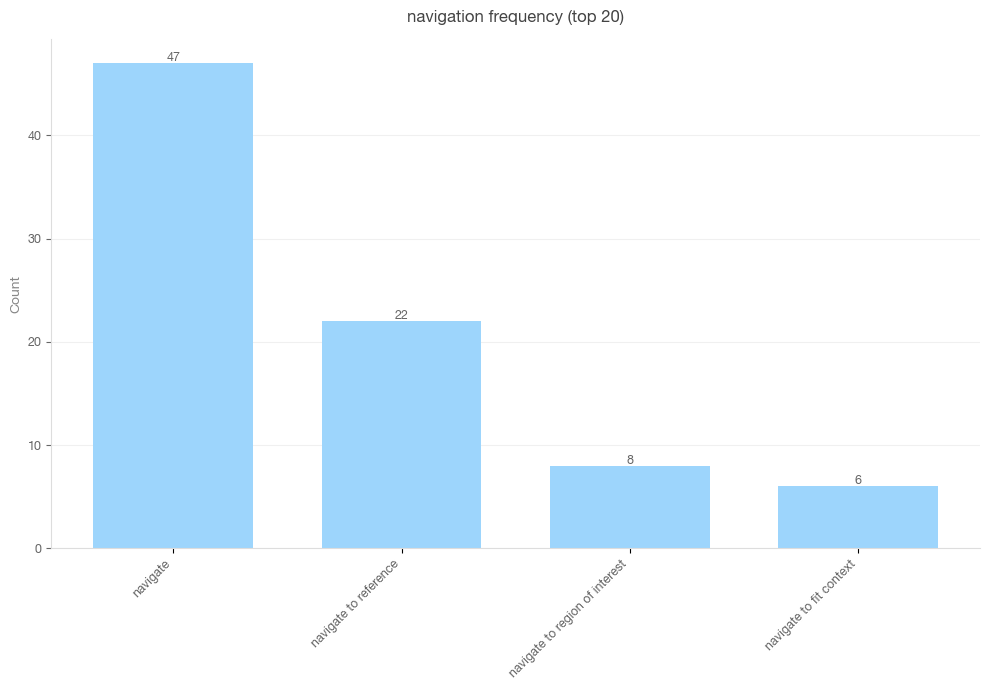

In [445]:
df_plot = df_navigation["tag_secondary"].value_counts().sort_values(ascending=False)
create_bar(df_plot, num=20, output="navigation")

## Subgraphs based on positioning

/var/folders/hd/bt5ny1sx6hz3vyh2p56cyyvc0000gn/T/ipykernel_38930/3619881053.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_plot.index, rotation=45, ha="right", fontsize=9, color="#666")


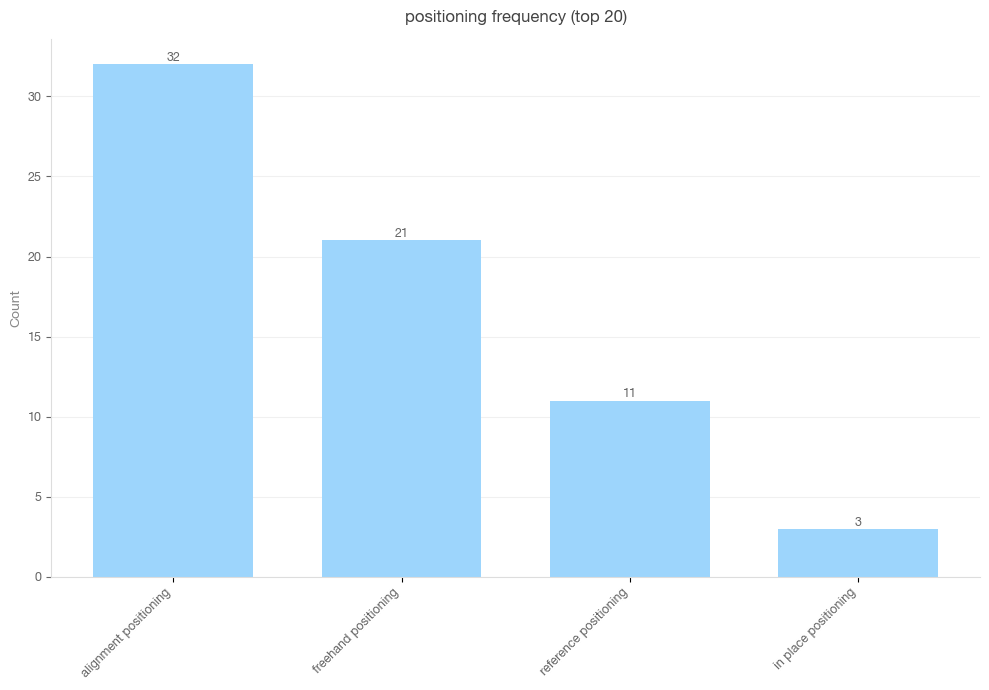

In [446]:
df_positioning = df[
    (df["tag_primary"] == "positioning") |
    (df["tag_secondary"].str.contains("positioning", na=False)) |
    # (df["tag_secondary"].str.contains("reference", na=False)) |
    (df["tag_secondary"].str.contains("creating design object", na=False)) |
    (df["tag_secondary"].str.contains("creating spline object", na=False))
    # (df["tag_secondary"].str.contains("in place", na=False)) |
    # (df["tag_secondary"].str.contains("freehand", na=False)) 
]

rules = {
    "alignment positioning": "alignment",
    "reference positioning": "reference",
    "freehand positioning": "freehand",
    "in place positioning": "in place",
}

df_positioning["positioning_type"] = "other positioning"

for label, key in rules.items():
    mask = df_positioning["tag_secondary"].str.contains(key, case=False, na=False)
    df_positioning.loc[mask, "positioning_type"] = label

df_plot = df_positioning["positioning_type"].value_counts().sort_values(ascending=False)
create_bar(df_plot, num=20, output="positioning")

In [447]:
# def plot_timeline(sample, label_type="tag", n_tags=9, min_width=0.6, bar_height=0.9):
#     top_tags = df[label_type].value_counts().head(n_tags).index.tolist()
#     plot_df = (
#         df[(df["sample"] == sample) & (df[label_type].isin(top_tags))]
#         .dropna(subset=[label_type, "adjusted_start", "adjusted_end"])
#         .copy()
#     )

#     fig, ax = plt.subplots(figsize=(12, 3.2))
#     fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

#     for i, tag in enumerate(top_tags):
#         tag_df = plot_df[plot_df[label_type] == tag]
#         for _, row in tag_df.iterrows():
#             width = row["adjusted_end"] - row["adjusted_start"]
#             ax.barh(i, max(width, min_width), left=row["adjusted_start"],
#                     height=bar_height, color=global_color_map[tag], edgecolor="none")

#     ax.set_yticks(range(len(top_tags)))
#     ax.set_yticklabels(top_tags, fontsize=9, color="#666")
#     ax.set_xlim(plot_df["adjusted_start"].min() - 1, plot_df["adjusted_end"].max() + 1)
#     ax.set_title(f"Actions over time — {sample}", fontsize=12,
#                  color="#333", pad=14, fontweight="bold", loc="left")
#     ax.spines[["top", "right", "left"]].set_visible(False)
#     ax.spines["bottom"].set_color("#e0e0e0")
#     ax.xaxis.grid(True, color="#eeeeee", zorder=0)
#     ax.set_xlabel("Time (s)", fontsize=9, color="#888")
#     ax.set_axisbelow(True)
#     ax.tick_params(length=0, colors="#aaa", labelsize=8)
#     plt.tight_layout()
#     plt.savefig(f"figures/{sample}.png", dpi=150, bbox_inches="tight", facecolor=BG)
#     plt.show()


# for sample in sorted(df["sample"].unique()):
#     plot_timeline(sample, label_type="secondary")

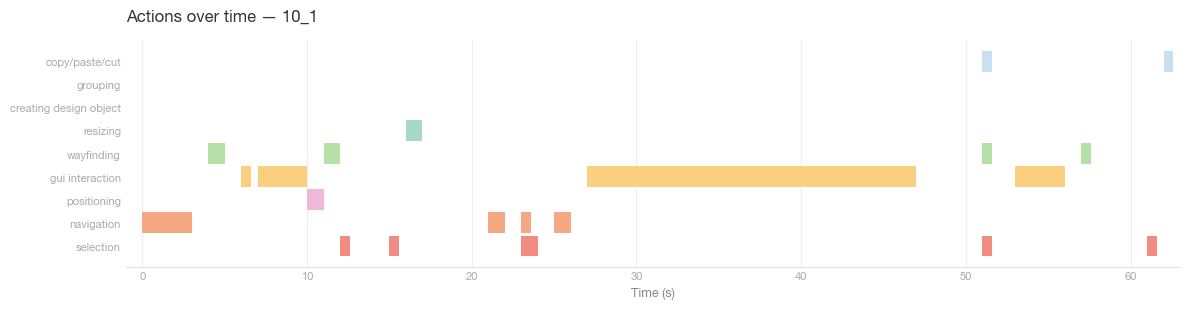

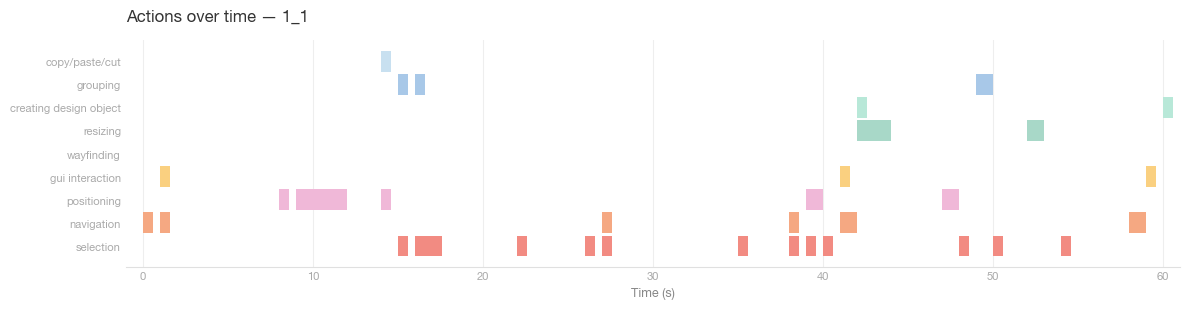

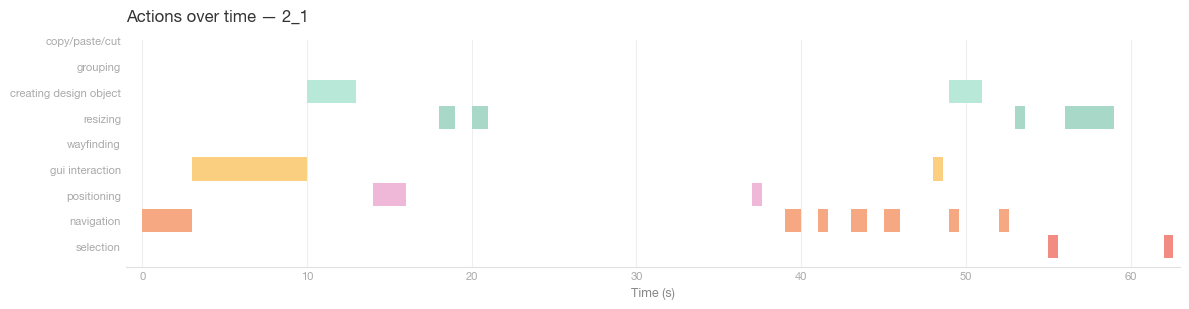

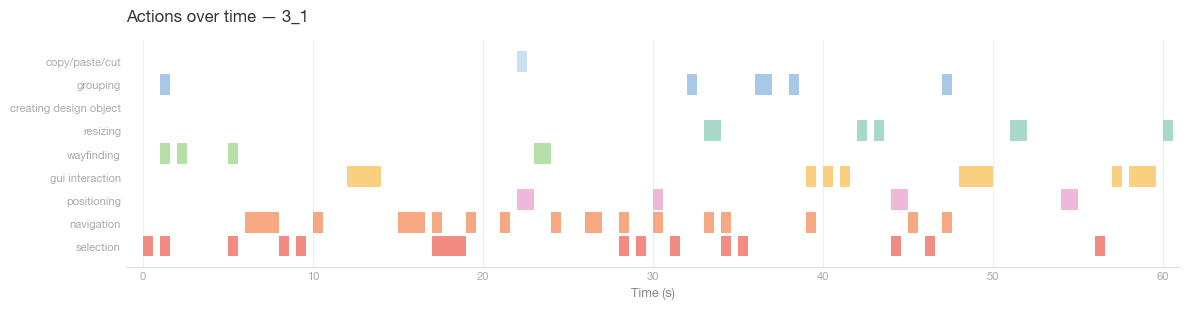

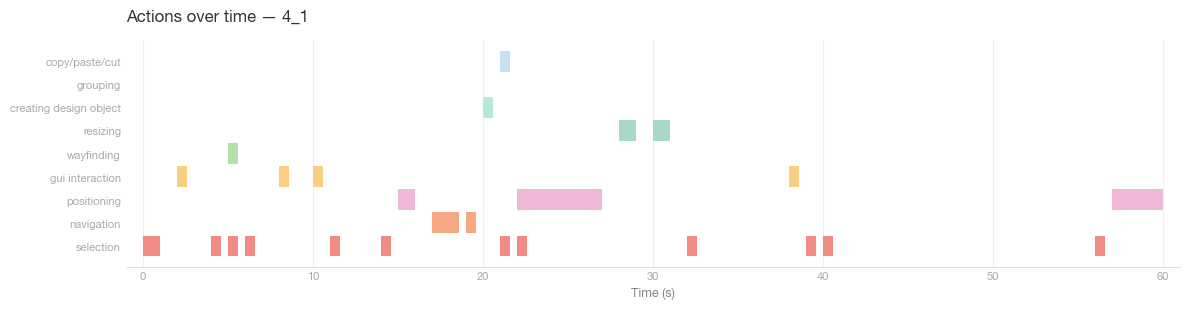

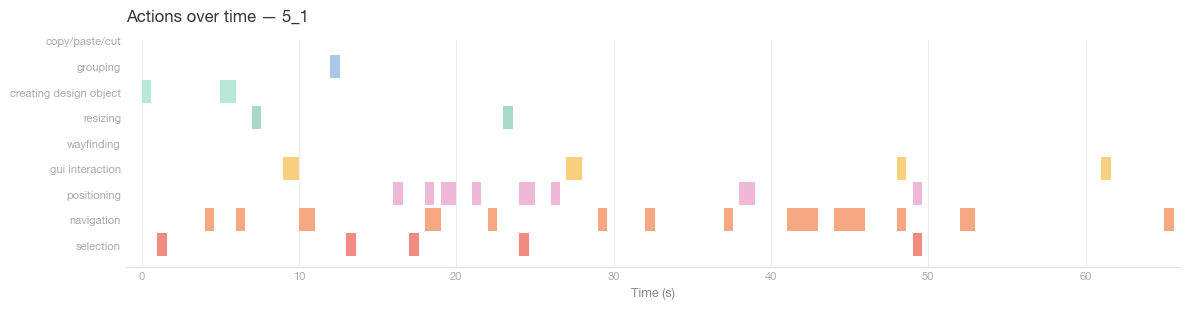

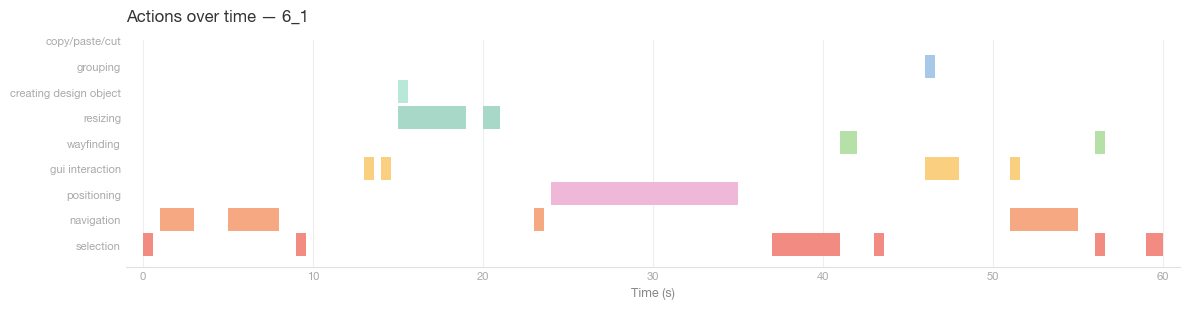

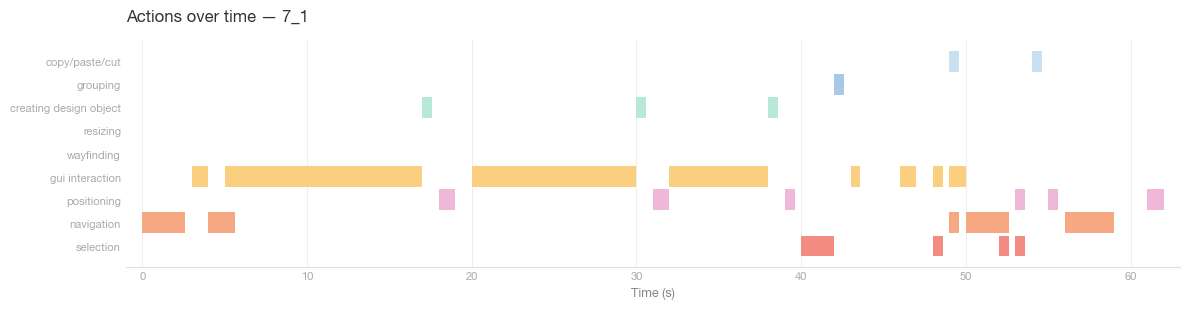

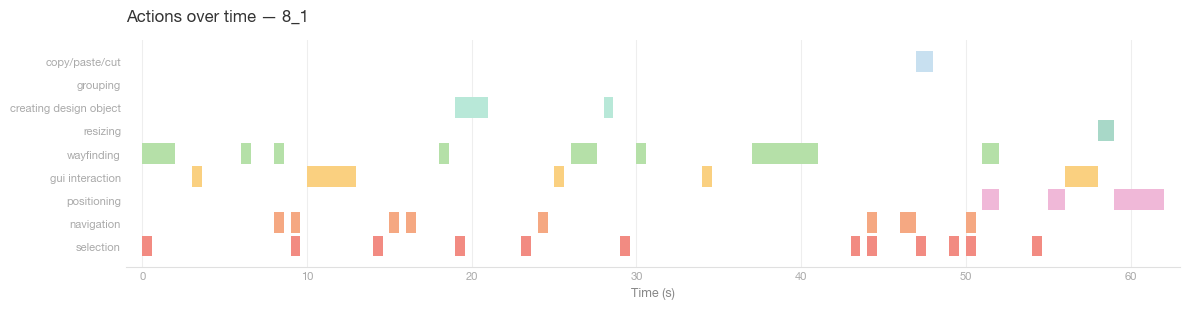

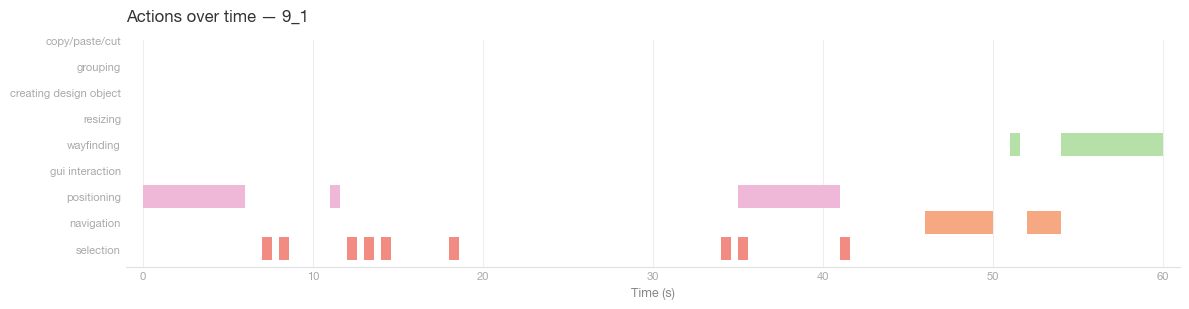

In [448]:
def plot_timeline(sample, n_tags=9, min_width=0.6, bar_height=0.9):
    top_tags = df["tag"].value_counts().head(n_tags).index.tolist()
    plot_df = (
        df[(df["sample"] == sample) & (df["tag"].isin(top_tags))]
        .dropna(subset=["tag", "adjusted_start", "adjusted_end"])
        .copy()
    )

    fig, ax = plt.subplots(figsize=(12, 3.2))
    fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

    for i, tag in enumerate(top_tags):
        tag_df = plot_df[plot_df["tag"] == tag]
        for _, row in tag_df.iterrows():
            width = row["adjusted_end"] - row["adjusted_start"]
            ax.barh(i, max(width, min_width), left=row["adjusted_start"],
                    height=bar_height, color=global_color_map[tag], edgecolor="none")

    ax.set_yticks(range(len(top_tags)))
    ax.set_yticklabels(top_tags, fontsize=9, color="#666")
    ax.set_xlim(plot_df["adjusted_start"].min() - 1, plot_df["adjusted_end"].max() + 1)
    ax.set_title(f"Actions over time — {sample}", fontsize=12,
                 color="#333", pad=14, fontweight="bold", loc="left")
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color("#e0e0e0")
    ax.xaxis.grid(True, color="#eeeeee", zorder=0)
    ax.set_xlabel("Time (s)", fontsize=9, color="#888")
    ax.set_axisbelow(True)
    ax.tick_params(length=0, colors="#aaa", labelsize=8)
    plt.tight_layout()
    plt.savefig(f"figures/sample_{sample}.png", dpi=150, bbox_inches="tight", facecolor=BG)
    plt.show()


for sample in sorted(df["sample"].unique()):
    plot_timeline(sample)

# Adding Difficulty Tags in Post
Colour = weighted difficulty score (Easy=1, Medium=3, Hard=8, Very Hard=20). Numbers = raw count.

In [449]:
# DIFF_ORDER   = ["EASY", "MEDIUM", "HARD", "VERY HARD"]
# diff_weights = {"EASY": 1, "MEDIUM": 3, "HARD": 8, "VERY HARD": 20}

# heatmap_counts = (
#     df.groupby(["tag_group", "difficulty"])
#     .size()
#     .unstack(fill_value=0)
#     .reindex(columns=DIFF_ORDER, fill_value=0)
# )

# heatmap_weighted = heatmap_counts.mul(pd.Series(diff_weights).reindex(DIFF_ORDER), axis=1)

# top_tags         = heatmap_weighted.sum(axis=1).sort_values(ascending=False).head(12).index
# heatmap_weighted = heatmap_weighted.loc[top_tags]
# heatmap_counts   = heatmap_counts.loc[top_tags]

# annot = heatmap_counts.astype(str)
# annot[heatmap_counts == 0] = ""

# fig, ax = plt.subplots(figsize=(8, max(5, len(heatmap_weighted) * 0.6)))
# sns.heatmap(
#     heatmap_weighted,
#     annot=annot, fmt="",
#     cmap="YlOrRd",
#     linewidths=0.5, linecolor="#eee",
#     cbar_kws={"label": "Weighted difficulty score"},
#     ax=ax
# )
# ax.set_title("Tag × Difficulty\ncolour = weighted score, numbers = raw count",
#              fontsize=11, color="#444", pad=12)
# ax.set_xlabel("Difficulty", color="#666")
# ax.set_ylabel("Tag", color="#666")
# plt.tight_layout()
# plt.savefig("figures/tag_difficulty_heatmap.png", dpi=150, bbox_inches="tight")
# plt.show()